In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import os   
def plot_makespan_vs_num_tasks(num_tasks, makespan_list, algorithm_names, filename, title='Makespan Comparison'):
    """绘制任务数量与工期之间的关系"""
    sns.set(style="whitegrid")  # 设置带虚线网格的白色背景

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # 定义颜色和样式
    colors = ['dodgerblue', 'red', 'magenta', 'black']  # 颜色列表
    markers = ['o', 's', 'D', '^']  # 不同的标记样式
    linestyles = ['--', '-', ':', '-.']  # 不同的线条样式

    for i, makespan in enumerate(makespan_list):
        ax.plot(num_tasks, makespan, 
                marker=markers[i],  # 使用不同的标记
                color=colors[i],
                linestyle=linestyles[i],  
                linewidth=2,  # 增加线条宽度
                markersize=8,  # 增大标记大小
                label=algorithm_names[i])  # 添加标签

    # 设置轴和标题
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Number of Tasks', size=14)
    # ax.set_ylabel('Makespan(s)', size=14)
    
    # 根据标题设置 Y 轴标签
    if title == 'Makespan Comparison':
        ax.set_ylabel('Makespan(s)', size=14)
    elif title == 'Energy Consumption':
        ax.set_ylabel('Energy(J)', size=14)

    if title:
        ax.set_title(title, size=16)

    # 设置x轴刻度
    ax.set_xticks([5, 10, 15, 20, 25, 30])  # 仅标注整数
    ax.set_xticklabels([5, 10, 15, 20, 25, 30])
    
    ax.yaxis.grid(True, linestyle='--', linewidth=1)
    ax.xaxis.grid(True, linestyle='--', linewidth=1)

    # 添加图例
    ax.legend()
    
    # 确保结果文件夹存在
    output_dir = './'
    os.makedirs(output_dir, exist_ok=True)

    filename 
    # 保存为EPS格式到指定目录
    plt.savefig(os.path.join(output_dir, f"{filename.replace(' ', '_')}.eps"), format='eps')  # 使用标题作为文件名，替换空格为下划线

    # 保存和显示
    fig.tight_layout()
    plt.show()
    return

In [9]:
from dag_power import DGF_algorithm

# structure = "FFT"  # 可选 "GE" 或 "FFT"

for structure in ["FFT", "GE"]:
    num_nodes = 25  # 节点数量
    B_total = [50]  # Total bandwidth
    P_max = [60]  # Maximum power
    num_task_max = 31

    algorithms = ["grasp", "greedy", "random", "convex"]  # 可选算法列表
    num_tasks_list = []  # 创建一个列表来存储任务数量
    makespan_list = [[] for _ in algorithms]  # 创建一个列表来存储每个算法的工期
    best_objective_list = [[] for _ in algorithms]  # 创建一个列表来存储每个算法的最佳目标值

    for num_tasks in range(5, num_task_max, 5):  # 从5到30，每隔5个单位
        num_tasks_list.append(num_tasks)  # 将当前任务数量添加到列表中
        for i, selected_algorithm in enumerate(algorithms):
            T_makespan, best_objective = DGF_algorithm(structure, num_tasks, num_nodes, B_total, P_max, selected_algorithm)
            makespan_list[i].append(T_makespan)  # 将当前工期添加到对应算法的列表中
            best_objective_list[i].append(best_objective)  # 将最佳目标值添加到对应算法的列表中


    best_objective_list
    import json
    import numpy as np

    # 构建文件名
    model = structure  # 从之前的代码中获取
    num = num_nodes
    # 将 makespan_list 中的 NumPy 数组转换为列表
    for i in range(len(makespan_list)):
        makespan_list[i] = [item.tolist() if isinstance(item, np.ndarray) else item for item in makespan_list[i]]
        
    # latency = "50"  # 从 B_total 获取
    data_to_save = {
        "best_objective_list": best_objective_list,
        "makespan_list": makespan_list
    }

    # 构建文件名
    filename = f"{model}-{num}.json"
    # makespan_list_json = makespan_list.tolist()
    # 将数据保存为JSON文件
    with open(f"./result/{filename}", 'w') as f:
        json.dump(data_to_save, f)


生成的任务依赖关系: [(0, 1), (2, 3), (0, 2), (1, 3)]
GRASP算法总工期: 9.0 [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]]
------------------------phase 1 finished -----------------------------------
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel(R) Xeon(R) CPU E5-2687W 0 @ 3.10GHz, instruction set [SSE2|AVX]
Thread count: 16 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 419 rows, 450 columns and 1305 nonzeros
Model fingerprint: 0x3e4176cb
Model has 45 quadratic objective terms
Variable types: 315 continuous, 135 integer (135 binary)
Coefficient statistics:
  Matrix range     [3e-01, 5e

In [40]:
best_objective_list
import json
import numpy as np

# 构建文件名
model = structure  # 从之前的代码中获取
num = num_nodes
# 将 makespan_list 中的 NumPy 数组转换为列表
for i in range(len(makespan_list)):
    makespan_list[i] = [item.tolist() if isinstance(item, np.ndarray) else item for item in makespan_list[i]]
    
# latency = "50"  # 从 B_total 获取
data_to_save = {
    "best_objective_list": best_objective_list,
    "makespan_list": makespan_list
}

# 构建文件名
filename = f"{model}-{num}.json"
# makespan_list_json = makespan_list.tolist()
# 将数据保存为JSON文件
with open(f"./result/{filename}", 'w') as f:
    json.dump(data_to_save, f)


# algorithm_names = ['Execute Locally', 'MEC Offloading', 'JOOA']

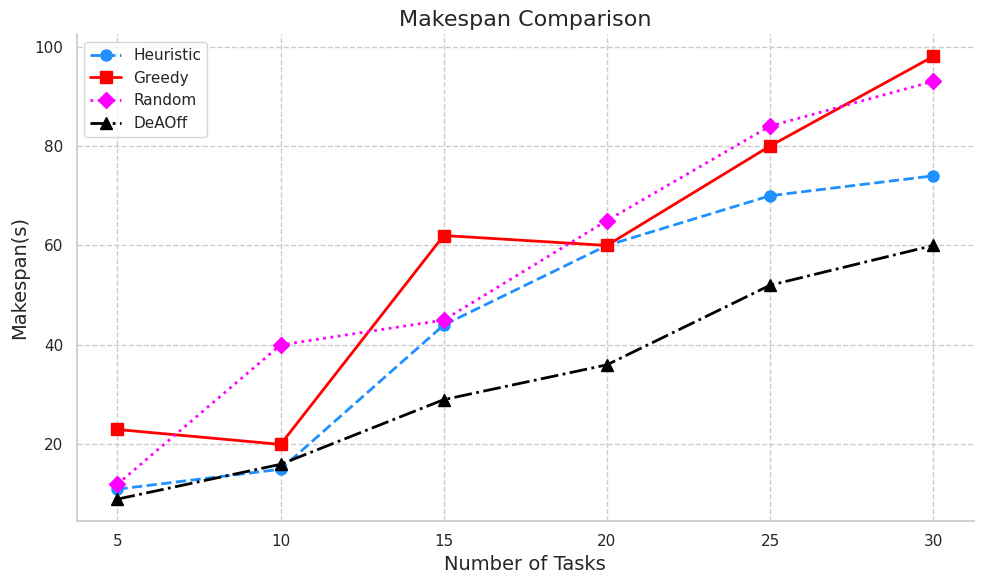

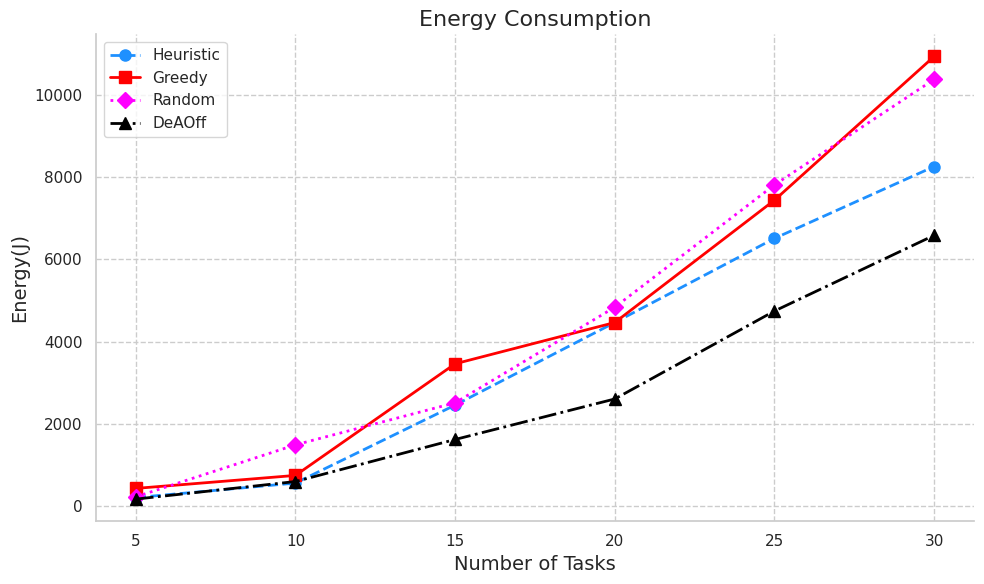

In [ ]:

algorithm_names = ['Heuristic', 'Greedy', 'Random', 'DeAOff']
plot_makespan_vs_num_tasks(num_tasks_list, makespan_list, algorithm_names, title='Makespan Comparison')

algorithm_names = ['Heuristic', 'Greedy', 'Random', 'DeAOff']  # 确保与算法列表一致
plot_makespan_vs_num_tasks(num_tasks_list, best_objective_list, algorithm_names, title='Energy Consumption')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


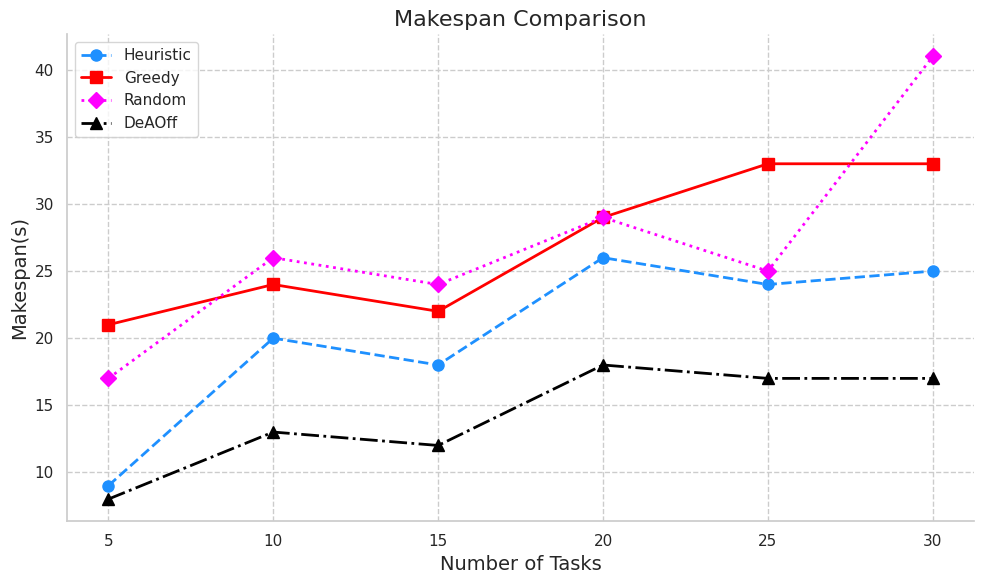

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


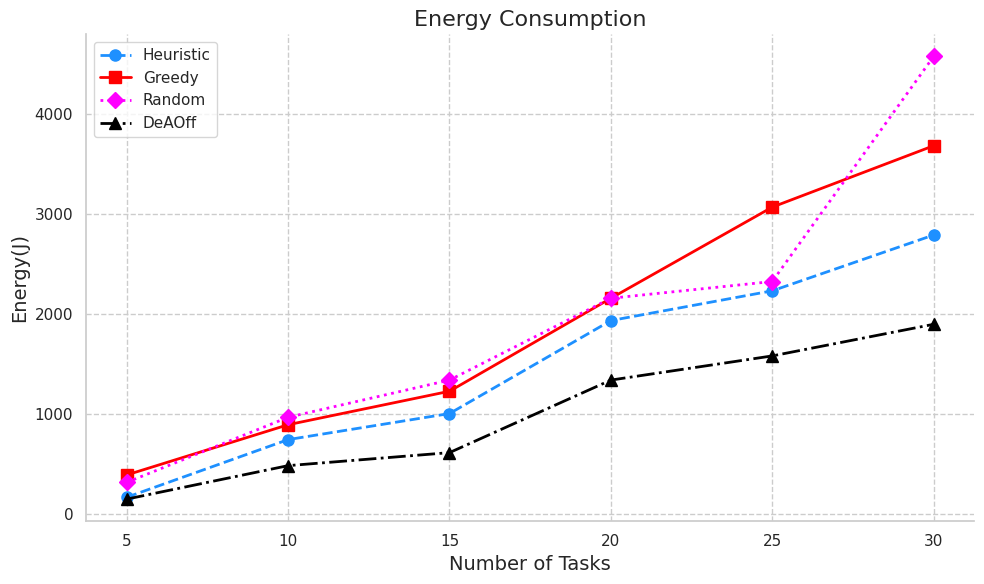

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


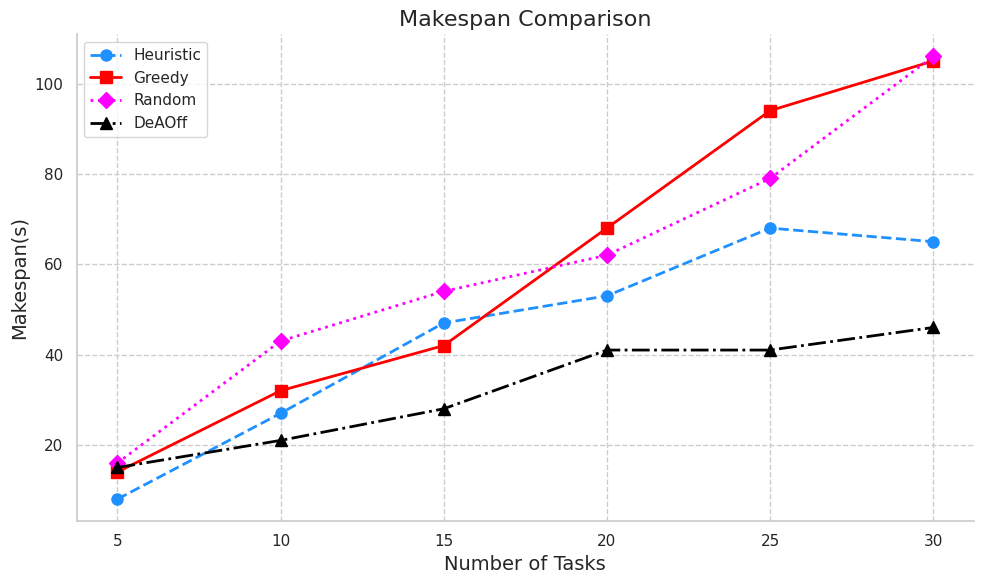

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


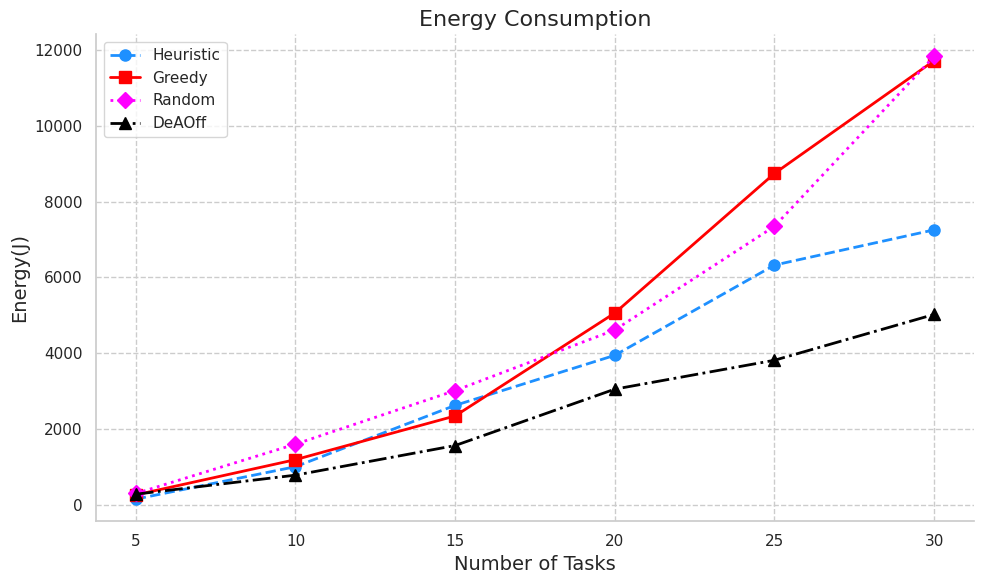

In [11]:
import json
import os

# 指定结果文件路径
index = './result/'
for model in ['FFT', 'GE']:
    fft_file_path = index + model + '-25'

    # 从JSON文件中读取数据
    with open(fft_file_path+'.json', 'r') as f:
        data = json.load(f)

    # 假设数据结构是一个列表，包含多个算法的结果
    # 这里我们将数据分配给 makespan_list 和 best_objective_list
    makespan_list = data['makespan_list']  # 提取工期列表
    best_objective_list = data['best_objective_list']  # 提取最佳目标值列表

    # 假设你有一个 num_tasks_list 变量，表示任务数量
    num_tasks_list = [5, 10, 15, 20, 25, 30]  # 根据你的实际情况调整

    # 使用读取的数据进行绘图
    algorithm_names = ['Heuristic', 'Greedy', 'Random', 'DeAOff']  # 确保与算法列表一致

    plot_makespan_vs_num_tasks(num_tasks_list, makespan_list, algorithm_names, fft_file_path+'-Latency', title='Makespan Comparison')
    plot_makespan_vs_num_tasks(num_tasks_list, best_objective_list, algorithm_names, fft_file_path+'-Energy', title='Energy Consumption')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


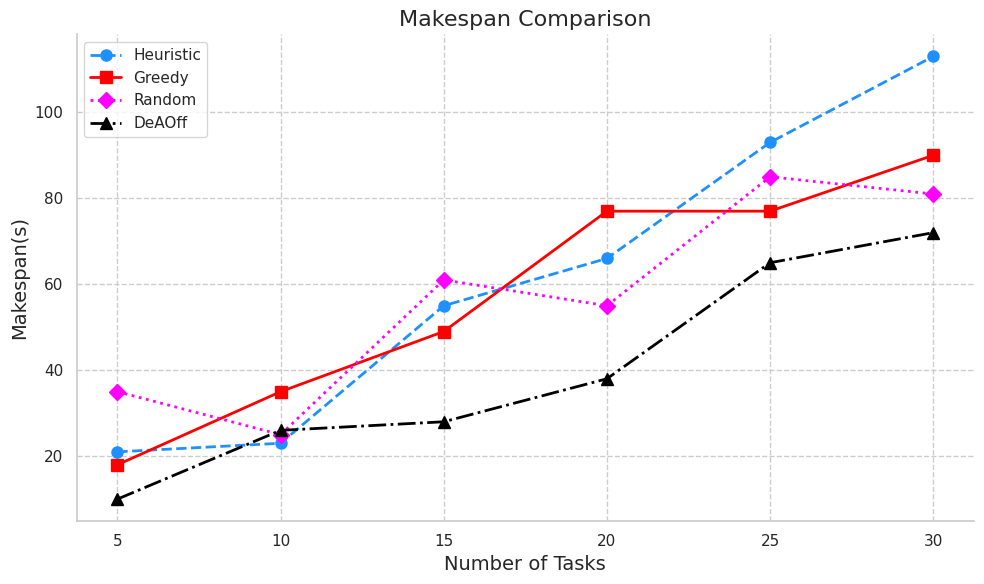

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


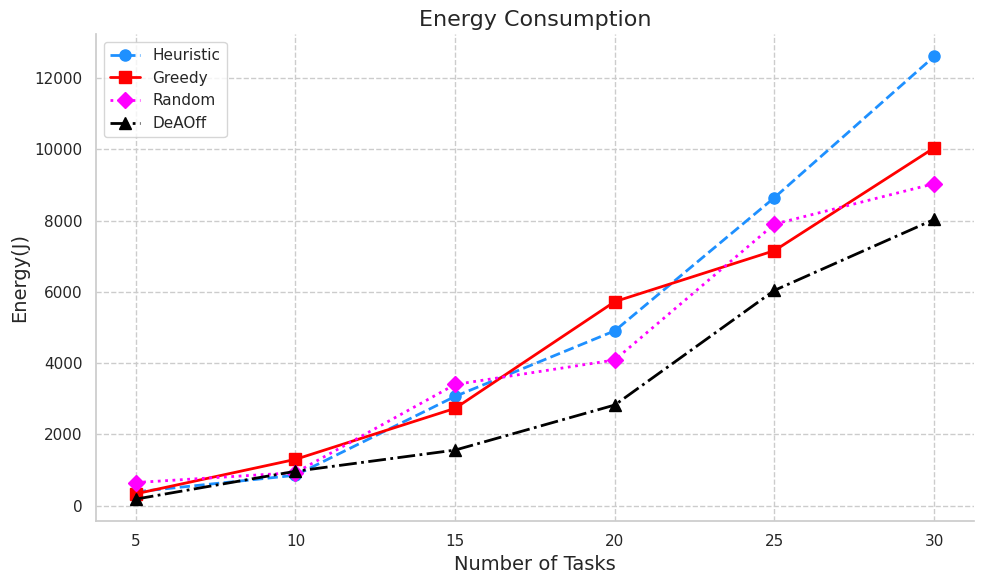

In [39]:
import json
import os

# 指定结果文件路径
index = './result/'
fft_file_path = index + 'GE-5'

# 从JSON文件中读取数据
with open(fft_file_path+'.json', 'r') as f:
    data = json.load(f)

# 假设数据结构是一个列表，包含多个算法的结果
# 这里我们将数据分配给 makespan_list 和 best_objective_list
makespan_list = data['makespan_list']  # 提取工期列表
best_objective_list = data['best_objective_list']  # 提取最佳目标值列表

# 假设你有一个 num_tasks_list 变量，表示任务数量
num_tasks_list = [5, 10, 15, 20, 25, 30]  # 根据你的实际情况调整

# 使用读取的数据进行绘图
algorithm_names = ['Heuristic', 'Greedy', 'Random', 'DeAOff']  # 确保与算法列表一致

plot_makespan_vs_num_tasks(num_tasks_list, makespan_list, algorithm_names, fft_file_path+'-Latency', title='Makespan Comparison')
plot_makespan_vs_num_tasks(num_tasks_list, best_objective_list, algorithm_names, fft_file_path+'-Energy', title='Energy Consumption')